# Trader Performance vs Market Sentiment Analysis
#### Candidate: Manav Kumar
#### Submitted for Primetrade.ai Internship Screening Assignment

## Objective

To analyze the relationship between Bitcoin Fear & Greed sentiment and trader performance using Hyperliquid historical trading data.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")
print("Loaded both datasets successfully.")

Loaded both datasets successfully.


In [3]:
print(trades.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [4]:
print(sentiment.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [5]:
# Checking datasets structures and information
print(trades.info())
print()
print(sentiment.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

## Data Cleaning

In [6]:
trades.columns = trades.columns.str.strip()
sentiment.columns = sentiment.columns.str.strip()

trades['Date'] = pd.to_datetime(trades['Timestamp IST'] , dayfirst = True).dt.date
sentiment['Date'] = pd.to_datetime(sentiment['date'] , yearfirst = True).dt.date

'''alternative for mixed timestamp format - 
trades['Date'] = pd.to_datetime(trades['Timestamp IST'] , format = 'mixed').dt.date
sentiment['Date'] = pd.to_datetime(sentiment['date'] , format = 'mixed').dt.date
'''
print("Converted timestamps, cleaned column names.")

Converted timestamps, cleaned column names.


## Feature Engineering (Merging Datasets for Key Insights)

In [7]:
df = trades.merge(sentiment, on='Date', how='left')
print("Merged trading records with daily sentiment labels.")

Merged trading records with daily sentiment labels.


In [8]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
 16  Date              21

## Main Analysis: Trader Performance vs Market Sentiment (Exploratory Data Analysis)

In [10]:
#Average Profit/Loss by Sentiment
pnl_avg = df.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False).reset_index()
print(pnl_avg)

  classification  Closed PnL
0  Extreme Greed   67.892861
1           Fear   54.290400
2          Greed   42.743559
3   Extreme Fear   34.537862
4        Neutral   34.307718


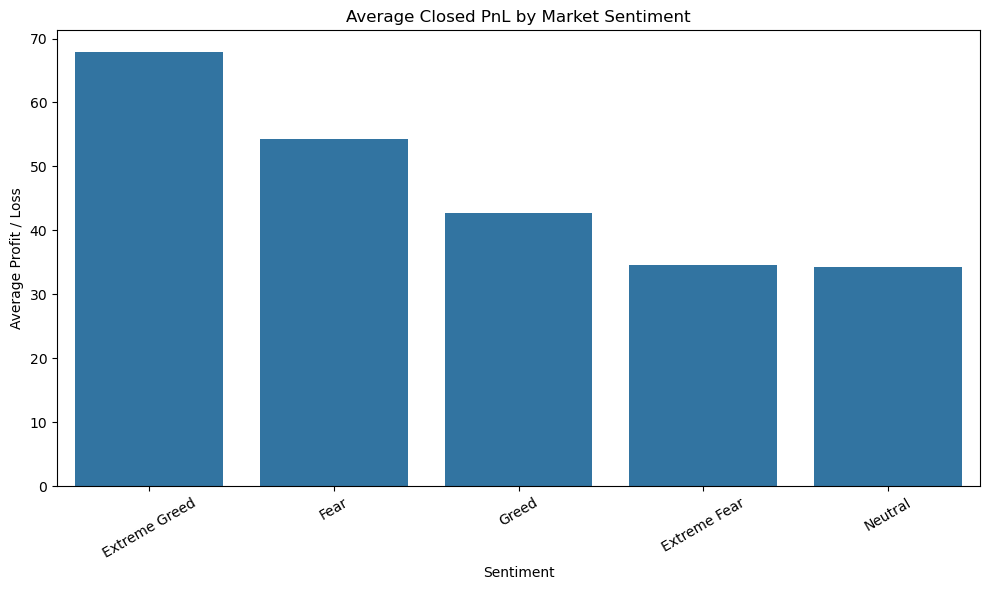

This shows whether traders were more profitable during Fear or Greed market conditions.


In [11]:
fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=pnl_avg,
    x="classification",
    y="Closed PnL",
    ax=ax
)

ax.set_title("Average Closed PnL by Market Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Average Profit / Loss")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print("This shows whether traders were more profitable during Fear or Greed market conditions.")

In [12]:
#Total Profit/Loss by Sentiment
pnl_total = df.groupby("classification")["Closed PnL"].sum().sort_values(ascending=False).reset_index()
print(pnl_total)

  classification    Closed PnL
0           Fear  3.357155e+06
1  Extreme Greed  2.715171e+06
2          Greed  2.150129e+06
3        Neutral  1.292921e+06
4   Extreme Fear  7.391102e+05


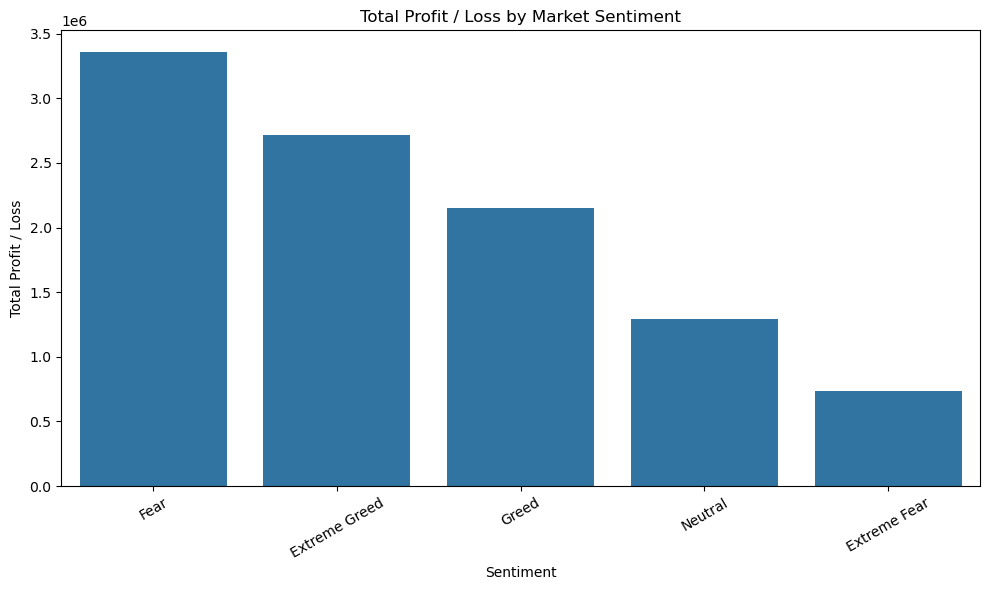

This shows total profit or loss.


In [13]:
fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=pnl_total,
    x="classification",
    y="Closed PnL",
    ax=ax
)

ax.set_title("Total Profit / Loss by Market Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Total Profit / Loss")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print("This shows total profit or loss.")

In [14]:
#Number of Trades by Sentiment
trade_count = df.groupby("classification").size().sort_values(ascending=False).reset_index(name = 'Trades')
print(trade_count)

  classification  Trades
0           Fear   61837
1          Greed   50303
2  Extreme Greed   39992
3        Neutral   37686
4   Extreme Fear   21400


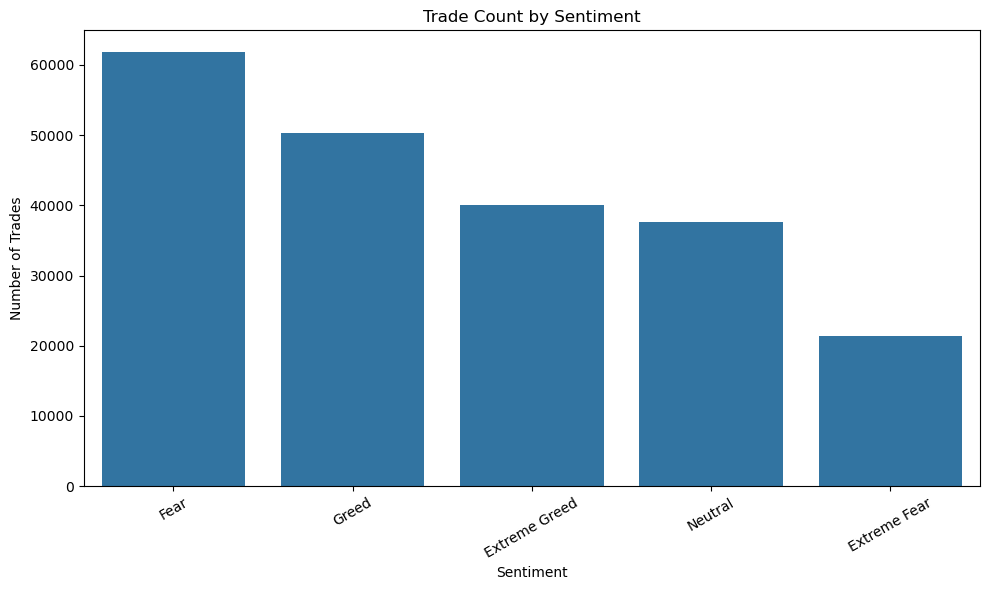

Higher trade count may indicate increased activity during optimistic markets.


In [15]:
fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=trade_count,
    x="classification",
    y="Trades",
    ax=ax
)

ax.set_title("Trade Count by Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Trades")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print("Higher trade count may indicate increased activity during optimistic markets.")

In [16]:
#Average Trade Size by Sentiment
size_avg = df.groupby("classification")["Size USD"].mean().reset_index()
print(size_avg)

  classification     Size USD
0   Extreme Fear  5349.731843
1  Extreme Greed  3112.251565
2           Fear  7816.109931
3          Greed  5736.884375
4        Neutral  4782.732661


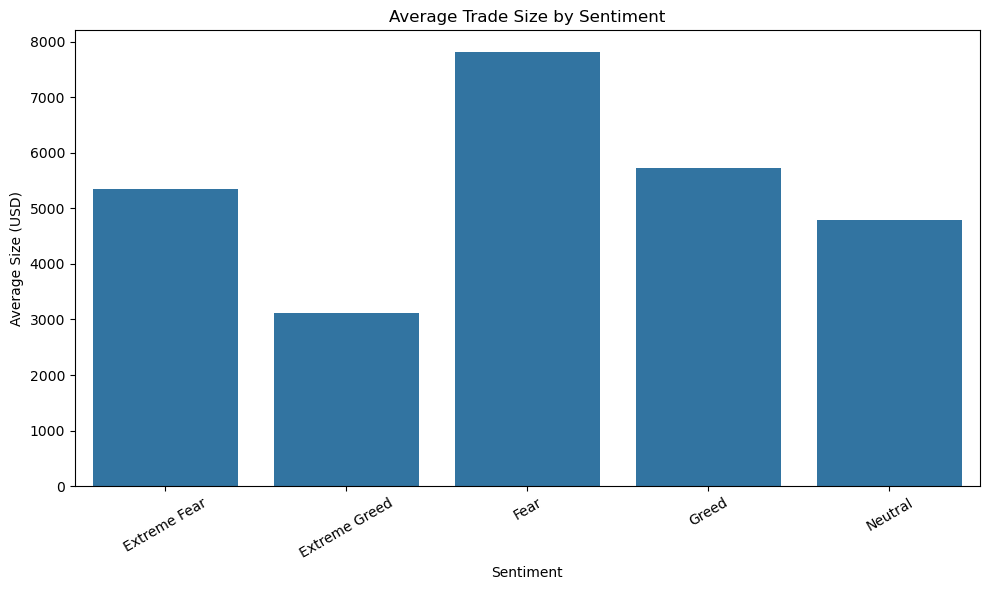

Bigger trade size = risk appetite.


In [17]:
fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=size_avg,
    x="classification",
    y="Size USD",
    ax=ax
)

ax.set_title("Average Trade Size by Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Average Size (USD)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print("Bigger trade size = risk appetite.")

In [18]:
#Buy vs Sell Performance
side_perf = df.groupby(["classification","Side"])["Closed PnL"].mean().reset_index()
print(side_perf)

  classification  Side  Closed PnL
0   Extreme Fear   BUY   34.114627
1   Extreme Fear  SELL   34.980106
2  Extreme Greed   BUY   10.498927
3  Extreme Greed  SELL  114.584643
4           Fear   BUY   63.927104
5           Fear  SELL   45.049641
6          Greed   BUY   25.002302
7          Greed  SELL   59.691091
8        Neutral   BUY   29.227429
9        Neutral  SELL   39.456408


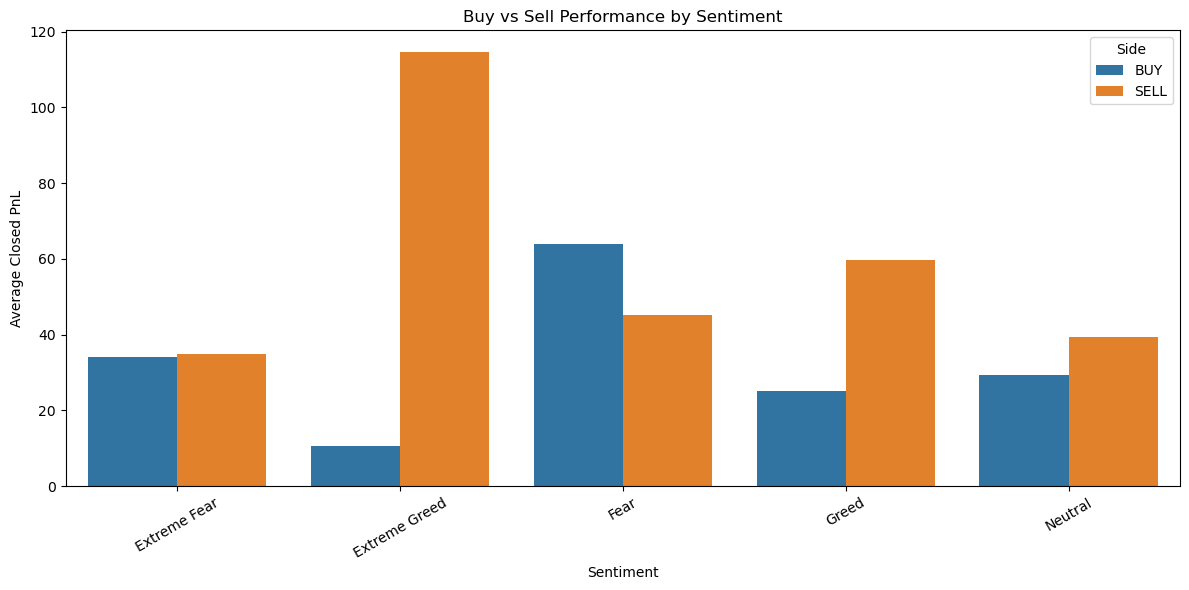

See whether Buy wins in Greed and Sell wins in Fear.


In [19]:
fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=side_perf,
    x="classification",
    y="Closed PnL",
    hue="Side",
    ax=ax
)

ax.set_title("Buy vs Sell Performance by Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Average Closed PnL")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print("See whether Buy wins in Greed and Sell wins in Fear.")

In [20]:
#Long vs Short Performance
dir_perf = df.groupby(["classification","Direction"])["Closed PnL"].mean().reset_index()
print(dir_perf)

   classification                  Direction    Closed PnL
0    Extreme Fear                        Buy      0.000000
1    Extreme Fear                 Close Long     81.197371
2    Extreme Fear                Close Short    123.400238
3    Extreme Fear               Long > Short      1.331956
4    Extreme Fear                  Open Long      0.000000
5    Extreme Fear                 Open Short      0.000000
6    Extreme Fear                       Sell   -135.021730
7    Extreme Fear               Short > Long  -1932.516940
8    Extreme Fear       Spot Dust Conversion      0.000000
9   Extreme Greed                        Buy      0.000000
10  Extreme Greed                 Close Long     61.830783
11  Extreme Greed                Close Short     28.970490
12  Extreme Greed               Long > Short    120.600968
13  Extreme Greed                  Open Long      0.000000
14  Extreme Greed                 Open Short      0.000000
15  Extreme Greed                       Sell    290.5723

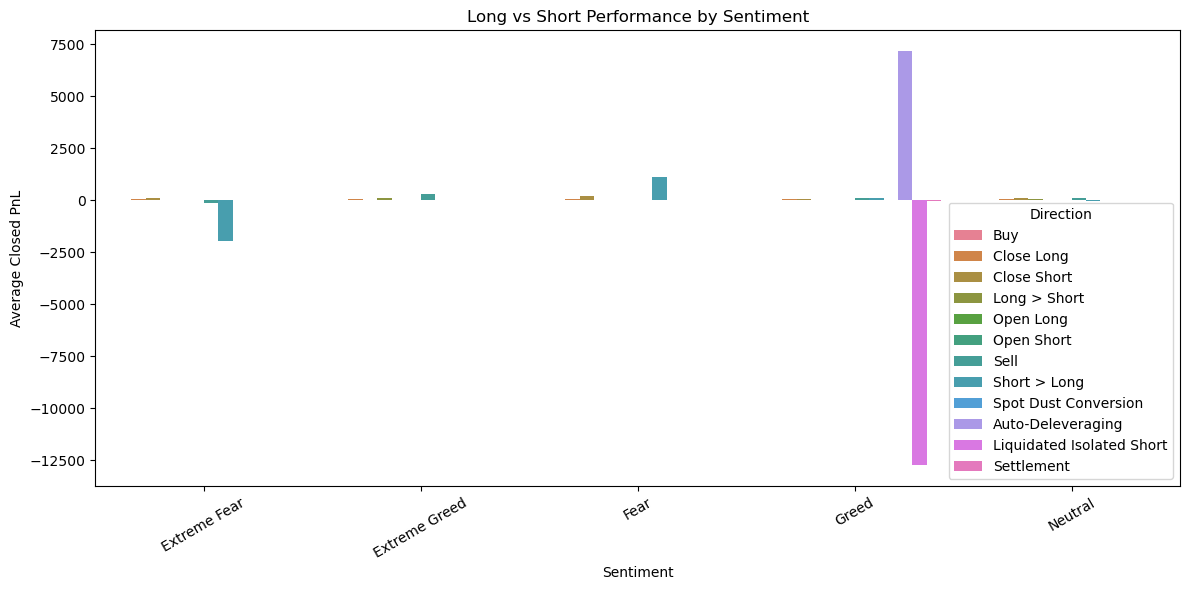

In [21]:
fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=dir_perf,
    x="classification",
    y="Closed PnL",
    hue="Direction",
    ax=ax
)

ax.set_title("Long vs Short Performance by Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Average Closed PnL")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [22]:
#Average Fees by Sentiment
fee_avg = df.groupby("classification")["Fee"].mean()
print(fee_avg)
print("More fees = more trading activity / bigger positions.")

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64
More fees = more trading activity / bigger positions.


In [23]:
#Coin-wise Most Traded Assets
top_coins = df["Coin"].value_counts().head(10).reset_index()
print(top_coins)

        Coin  count
0       HYPE  68005
1       @107  29992
2        BTC  26064
3        ETH  11158
4        SOL  10691
5   FARTCOIN   4650
6    MELANIA   4428
7  PURR/USDC   2774
8        WLD   1983
9        SUI   1979


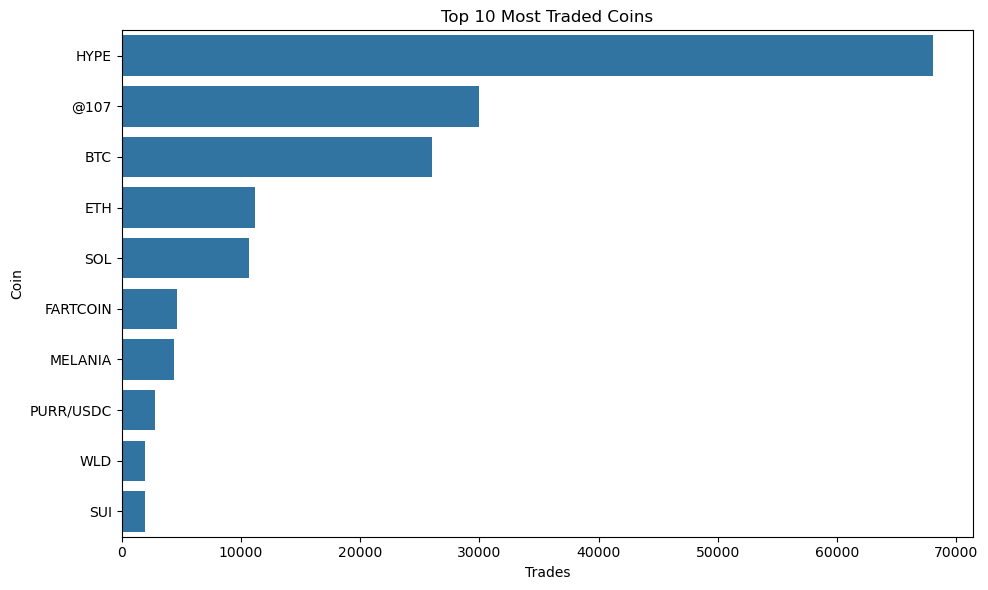

In [24]:
top_coins.columns = ["Coin", "Trades"]

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=top_coins,
    x="Trades",
    y="Coin",
    ax=ax
)

ax.set_title("Top 10 Most Traded Coins")
ax.set_xlabel("Trades")
ax.set_ylabel("Coin")
plt.tight_layout()
plt.show()

In [25]:
#Profit by Coin
coin_profit = df.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10)
print(coin_profit)

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


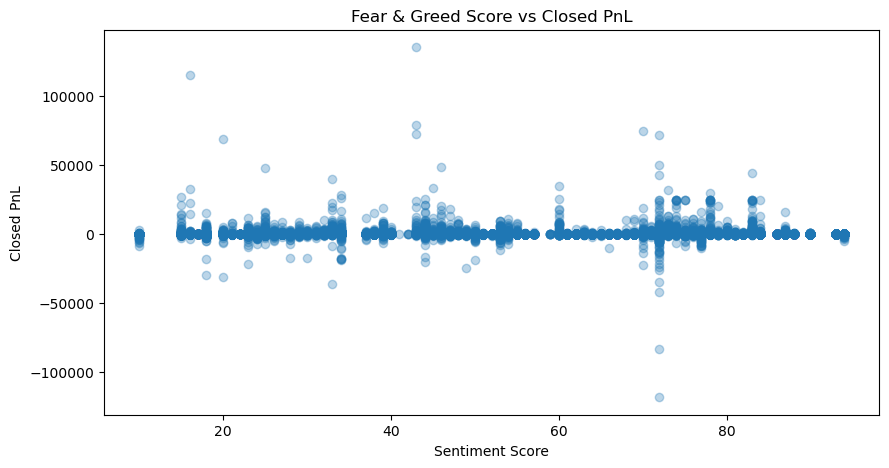

Checks whether profits rise with greed score.


In [26]:
#Fear & Greed Score vs Profit
plt.figure(figsize=(10,5))
plt.scatter(df["value"], df["Closed PnL"], alpha=0.3)
plt.title("Fear & Greed Score vs Closed PnL")
plt.xlabel("Sentiment Score")
plt.ylabel("Closed PnL")
plt.show()
print("Checks whether profits rise with greed score.")

In [27]:
#Win Rate by Sentiment
df["Win"] = df["Closed PnL"] > 0

win_rate = df.groupby("classification")["Win"].mean() * 100
print(win_rate)
print("Percentage of profitable trades.")

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64
Percentage of profitable trades.


## Final Conclusion
    Final Key Findings

    1. Traders were most profitable during Extreme Greed sentiment.
    2. Trade size increased during Fear periods.
    3. Buy/Sell strategies performed differently under varying sentiment.
    4. Sentiment appears to influence risk-taking behavior.
    5. Certain coins generated stronger profitability than others.